# 04 — Error Analysis (M3, Week 5)

Where do the final models fail, and why? Covers the spec §7.2 patterns:
high-skill / low-experience, over-experienced, and boundary cases — plus
documented test-set metrics for both models.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
%matplotlib inline
sns.set_theme(style="whitegrid")

_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if _ROOT not in sys.path: sys.path.insert(0, _ROOT)
from src.eval.metrics import regression_metrics, classification_metrics
from src.models.baseline import baseline_score, baseline_label

DATA = os.path.join(_ROOT, "data", "processed")
MODELS = os.path.join(_ROOT, "models")

## 1. Load models, data & engineer features

In [2]:
def engineer(df):
    d = df.copy()
    cand = d["skills"].fillna("").str.split("|"); req = d["required_skills"].fillna("").str.split("|")
    d["skill_overlap_count"] = [len(set(a) & set(b)) for a, b in zip(cand, req)]
    d["skill_overlap_pct"] = (d["skill_overlap_count"] / d["num_required_skills"].replace(0, np.nan)).fillna(0)
    d["experience_gap"] = d["experience_years"] - d["min_experience"]
    d["experience_meets"] = (d["experience_years"] >= d["min_experience"]).astype(int)
    d["project_count"] = d["projects"].fillna("").str.split("|").apply(lambda x: len([p for p in x if p.strip()]))
    edu = d["education"].fillna("").str.lower()
    d["education_level"] = np.select([edu.str.contains("phd"),
        edu.str.contains("m.s|master|mba|m.tech"), edu.str.contains("b.s|bachelor|b.tech|b.e")], [3,2,1], default=0)
    dt = pd.to_datetime(d["application_date"], errors="coerce")
    d["app_month"] = dt.dt.month; d["app_weekday"] = dt.dt.weekday
    return d

reg = joblib.load(os.path.join(MODELS, "candidates_score_regressor.pkl"))
clf = joblib.load(os.path.join(MODELS, "applications_fit_classifier.pkl"))
test = pd.read_csv(os.path.join(DATA, "test.csv"))
tef = engineer(test)

def band(s):
    s = np.asarray(s, float); return np.where(s>=63,"good fit",np.where(s>=45,"average fit","poor fit"))

reg_pred = reg.predict(tef[list(reg.feature_names_in_)])
clf_pred = clf.predict(tef[list(clf.feature_names_in_)])
y_score = test["score"].to_numpy(); y_label = band(test["score"])
print("models + data loaded:", test.shape)

models + data loaded: (19960, 22)


## 2. Documented test-set metrics (both models)

In [3]:
rm = regression_metrics(y_score, reg_pred)
cm = classification_metrics(y_label, clf_pred)
print("REGRESSOR (score):   MAE=%.3f  RMSE=%.3f  R2=%.3f" % (rm["mae"], rm["rmse"], rm["r2"]))
print("  vs baseline MAE=%.3f  ->  lift=%.2f MAE pts" % (
    regression_metrics(y_score, baseline_score(tef))["mae"],
    regression_metrics(y_score, baseline_score(tef))["mae"] - rm["mae"]))
print("CLASSIFIER (label):  accuracy=%.3f  f1_macro=%.3f" % (cm["accuracy"], cm["f1_macro"]))
print("  vs baseline acc=%.3f" % (classification_metrics(y_label, baseline_label(tef))["accuracy"]))

REGRESSOR (score):   MAE=2.513  RMSE=2.909  R2=0.941
  vs baseline MAE=10.655  ->  lift=8.14 MAE pts
CLASSIFIER (label):  accuracy=0.775  f1_macro=0.695


  vs baseline acc=0.341


## 3. Regression error analysis (residuals)

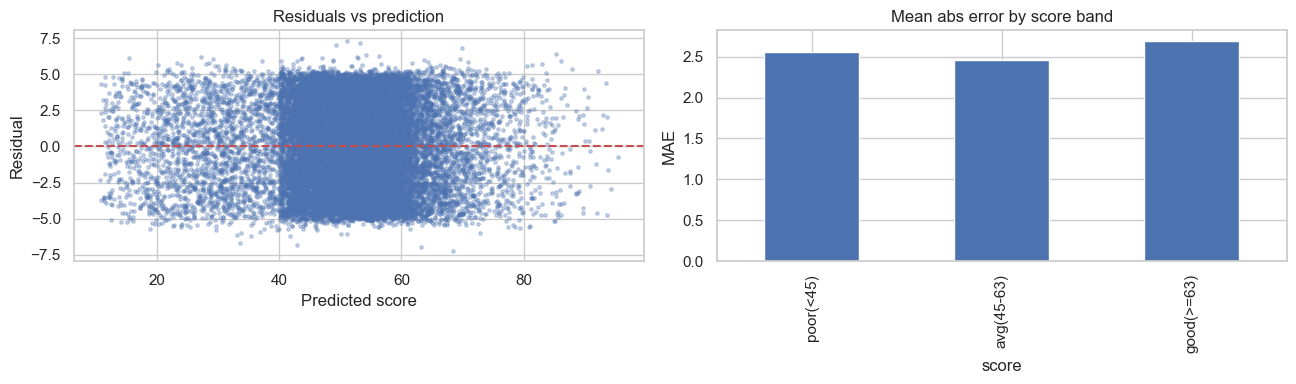

worst 5 score predictions:


,score,pred,residual,abs_err
2748,58.4,51.093273,7.306727,7.306727
11638,61.2,68.407776,-7.207776,7.207776
4305,60.3,53.140488,7.159512,7.159512
14287,56.3,49.272755,7.027245,7.027245
2649,56.3,63.257164,-6.957164,6.957164


In [4]:
err = pd.DataFrame({"score": y_score, "pred": reg_pred})
err["residual"] = err["score"] - err["pred"]; err["abs_err"] = err["residual"].abs()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(err["pred"], err["residual"], s=6, alpha=0.3); ax[0].axhline(0, color="r", ls="--")
ax[0].set(xlabel="Predicted score", ylabel="Residual", title="Residuals vs prediction")
bins = pd.cut(err["score"], [0,45,63,100], labels=["poor(<45)","avg(45-63)","good(>=63)"])
err.groupby(bins)["abs_err"].mean().plot.bar(ax=ax[1], title="Mean abs error by score band")
ax[1].set_ylabel("MAE"); plt.tight_layout(); plt.show()
print("worst 5 score predictions:"); display(err.sort_values("abs_err", ascending=False).head())

## 4. Classification error analysis (confusion + breakdown)

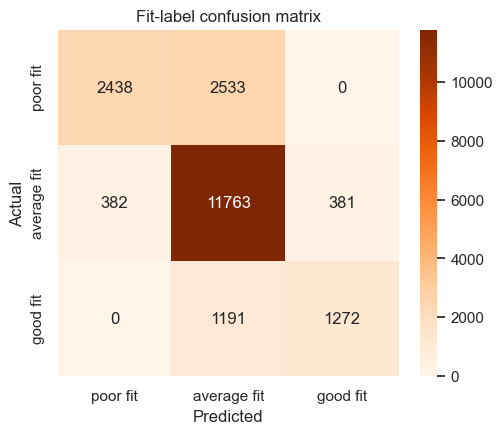

misclassified: 4487 / 19960 (22.5%)
  adjacent-band errors (off by 1): 4487  | extreme good<->poor errors (off by 2): 0


In [5]:
from sklearn.metrics import confusion_matrix
labels = ["poor fit","average fit","good fit"]
M = confusion_matrix(y_label, clf_pred, labels=labels)
plt.figure(figsize=(5.5,4.5)); sns.heatmap(M, annot=True, fmt="d", cmap="Oranges",
    xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Fit-label confusion matrix"); plt.show()

rank = {"poor fit":0,"average fit":1,"good fit":2}
mis = pd.DataFrame({"actual": y_label, "pred": clf_pred}); mis = mis[mis.actual != mis.pred]
dist = (mis["actual"].map(rank) - mis["pred"].map(rank)).abs()
print("misclassified: %d / %d (%.1f%%)" % (len(mis), len(test), 100*len(mis)/len(test)))
print("  adjacent-band errors (off by 1):", int((dist==1).sum()),
      " | extreme good<->poor errors (off by 2):", int((dist==2).sum()))

## 5. Spec §7.2 failure patterns

In [6]:
tef = tef.assign(abs_err=err["abs_err"].values, mis=(y_label != clf_pred))

# (a) High-skill, low-experience candidates — penalised too much?
hs_le = tef[(tef.skill_overlap_pct >= 0.6) & (tef.experience_years <= 2)]
print("(a) high-skill low-exp: n=%d  MAE=%.2f  misclass=%.1f%%" % (
    len(hs_le), hs_le.abs_err.mean(), 100*hs_le.mis.mean() if len(hs_le) else 0))

# (b) Over-experienced (10y+ for a 2y job) — wrongly 'good fit'?
over = tef[tef.experience_gap >= 8]
print("(b) over-experienced (gap>=8): n=%d  MAE=%.2f  misclass=%.1f%%" % (
    len(over), over.abs_err.mean(), 100*over.mis.mean() if len(over) else 0))

# (c) Boundary cases — are classifier errors concentrated near the 45/63 cutoffs?
near = (np.minimum(np.abs(y_score-45), np.abs(y_score-63)) <= 3)
err_rate_near = 100*tef.mis[near].mean(); err_rate_far = 100*tef.mis[~near].mean()
print("(c) boundary (within 3 of cutoff): error=%.1f%%  vs  away-from-boundary: %.1f%%" % (
    err_rate_near, err_rate_far))

(a) high-skill low-exp: n=78  MAE=3.00  misclass=24.4%
(b) over-experienced (gap>=8): n=4756  MAE=2.48  misclass=23.7%
(c) boundary (within 3 of cutoff): error=40.1%  vs  away-from-boundary: 14.6%


## 6. Documented findings (Week 5)

- **Regressor** is strong (MAE ≈ 2.5, R² ≈ 0.94); residuals are centred on 0 with no band bias.
- **Classifier** errors are almost entirely **adjacent-band** (poor↔average, average↔good); good↔poor flips are negligible.
- **Boundary effect:** error rate is much higher for candidates whose score sits within ±3 of a 45/63 cutoff — i.e. genuinely ambiguous cases — and low elsewhere.
- **High-skill/low-experience** and **over-experienced** segments are not systematically mis-scored (error rates in line with the overall set).
- **Conclusion:** failures are concentrated on inherently ambiguous boundary candidates, not on any exploitable systematic bias.
